# روش اول

In [67]:

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
# ============================================================
# CONFIG
# ============================================================
DATA_DIR = "./quadrature_data_4qubits"
NUM_QUBITS = 4
NUM_STATES = 2 ** NUM_QUBITS
SHOTS_PER_FILE = 1000
SAVE_DIR = "./noise_matrix_results"
os.makedirs(SAVE_DIR, exist_ok=True)
# ============================================================
# PARSE COMPLEX VALUES
# ============================================================
def parse_complex_string(s: str) -> complex:
    s = s.strip()
    if s.startswith("(") and s.endswith(")"):
        s = s[1:-1]
    return complex(s)
# ============================================================
# LOAD ONE FILE
# ============================================================
def load_single_file(file_path: str) -> np.ndarray:
    """
    Returns:
        array shape = (4, 1000)

        axis0 -> qubit
        axis1 -> shot
    """
    with open(file_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]
    if len(lines) != 4:
        raise ValueError(
            f"{file_path}: expected 4 lines, found {len(lines)}"
        )

    qubit_arrays = []
    for q, line in enumerate(lines):
        tokens = line.split()
        vals = [parse_complex_string(tok) for tok in tokens]
        arr = np.array(vals, dtype=np.complex128)
        if arr.size != SHOTS_PER_FILE:
            raise ValueError(
                f"{file_path}, line {q}: "
                f"expected {SHOTS_PER_FILE} samples, found {arr.size}"
            )
        qubit_arrays.append(arr)
    return np.stack(qubit_arrays, axis=0)
# ============================================================
# FILENAME -> LABEL
# ============================================================
def bits_from_filename(filename: str) -> np.ndarray:
    """
    filename example:
        0101.txt

    file naming convention:
        Q4 Q3 Q2 Q1

    returned label:
        [q1 q2 q3 q4]
    """
    base = os.path.splitext(os.path.basename(filename))[0]
    bits = [int(b) for b in base[::-1]]
    return np.array(bits, dtype=int)
# ============================================================
# LABEL <-> INTEGER
# ============================================================
def bits_to_int(bits):
    """
    Convert [q1 q2 q3 q4]
    into integer index 0..15

    q1 = LSB
    """
    q1, q2, q3, q4 = bits
    return (
        q1
        + 2 * q2
        + 4 * q3
        + 8 * q4
    )
def int_to_bits(x):

    return np.array([
        (x >> 0) & 1,
        (x >> 1) & 1,
        (x >> 2) & 1,
        (x >> 3) & 1,
    ])
# ============================================================
# LOAD ALL DATA
# ============================================================
def load_all_data():
    pattern = os.path.join(DATA_DIR, "[01][01][01][01].txt")
    file_paths = glob.glob(pattern)
    if len(file_paths) != 16:
        raise ValueError(
            f"Expected 16 files, found {len(file_paths)}"
        )
    file_paths = sorted(
        file_paths,
        key=lambda fp: int(
            os.path.splitext(os.path.basename(fp))[0],
            2
        )
    )
    X_all = []
    y_all = []
    for fp in file_paths:
        base = os.path.basename(fp)
        print(f"Loading {base}")
        data = load_single_file(fp)
        labels = bits_from_filename(fp)
        X_block = data.T
        y_block = np.tile(labels, (SHOTS_PER_FILE, 1))
        X_all.append(X_block)
        y_all.append(y_block)

    X = np.vstack(X_all)
    y = np.vstack(y_all)
    return X, y

In [68]:
# ============================================================
# BUILD SINGLE-QUBIT CLASSIFIERS
# ============================================================
def train_qubit_classifiers(X, y):
    classifiers = []
    for q in range(NUM_QUBITS):
        print(f"\nTraining classifier for qubit {q+1}")
        # --------------------------------------------
        # Features = [I, Q]
        # --------------------------------------------
        z = X[:, q]
        features = np.column_stack([z.real, z.imag])
        labels = y[:, q]
        # --------------------------------------------
        # Train LDA
        # --------------------------------------------
        clf = LinearDiscriminantAnalysis()
        clf.fit(features, labels)
        classifiers.append(clf)
        # --------------------------------------------
        # Evaluate single-qubit assignment matrix
        # --------------------------------------------
        pred = clf.predict(features)
        cm = confusion_matrix(
            labels,
            pred,
            labels=[0,1],
            normalize="true"
        )
        print("\nSingle-Qubit Assignment Matrix:")
        print(cm)
        np.save(
            os.path.join(
                SAVE_DIR,
                f"assignment_matrix_q{q+1}.npy"
            ),
            cm
        )
    return classifiers
# ============================================================
# PREDICT ALL SHOTS
# ============================================================
def predict_all_shots(X, classifiers):
    N = X.shape[0]
    pred_bits = np.zeros((N, NUM_QUBITS), dtype=int)
    for q in range(NUM_QUBITS):
        z = X[:, q]
        features = np.column_stack([z.real, z.imag])
        pred = classifiers[q].predict(features)
        pred_bits[:, q] = pred
    return pred_bits

In [69]:
# ============================================================
# BUILD FULL 16x16 NOISE MATRIX
# ============================================================
def build_noise_matrix(y_true, y_pred):
    noise_matrix = np.zeros(
        (NUM_STATES, NUM_STATES),
        dtype=float
    )
    # --------------------------------------------
    # Columns = prepared state
    # Rows    = measured state
    # --------------------------------------------
    for prep_state in range(NUM_STATES):
        prep_bits = int_to_bits(prep_state)
        mask = np.all(y_true == prep_bits, axis=1)
        pred_subset = y_pred[mask]
        total = pred_subset.shape[0]
        for measured_bits in pred_subset:
            meas_state = bits_to_int(measured_bits)
            noise_matrix[meas_state, prep_state] += 1
        noise_matrix[:, prep_state] /= total
    return noise_matrix

In [70]:
# ============================================================
# PLOT HEATMAP
# ============================================================
def plot_noise_matrix(matrix):
    plt.figure(figsize=(8,7))
    plt.imshow(matrix, origin="lower")
    plt.colorbar(label="Probability")
    tick_labels = [
        format(i, "04b")
        for i in range(NUM_STATES)
    ]
    plt.xticks(range(NUM_STATES), tick_labels, rotation=90)
    plt.yticks(range(NUM_STATES), tick_labels)
    plt.xlabel("Prepared State")
    plt.ylabel("Measured State")
    plt.title("16x16 Readout Noise Matrix")
    plt.tight_layout()
    out_path = os.path.join(
        SAVE_DIR,
        "noise_matrix_heatmap.png"
    )
    plt.savefig(out_path, dpi=300)
    plt.show()

In [71]:
# ============================================================
# SAVE MATRIX
# ============================================================
def save_noise_matrix(matrix):
    np.save(
        os.path.join(SAVE_DIR, "noise_matrix_16x16.npy"),
        matrix
    )
    np.savetxt(
        os.path.join(SAVE_DIR, "noise_matrix_16x16.txt"),
        matrix,
        fmt="%.8f"
    )

In [72]:
# ============================================================
# MAIN
# ============================================================
def main():
    print("\n================================================")
    print("LOADING DATA")
    print("================================================")
    X, y = load_all_data()
    print("\nX shape:", X.shape)
    print("y shape:", y.shape)
    # --------------------------------------------------------
    # Train classifiers
    # --------------------------------------------------------
    print("\n================================================")
    print("TRAINING CLASSIFIERS")
    print("================================================")
    classifiers = train_qubit_classifiers(X, y)
    # --------------------------------------------------------
    # Predict all shots
    # --------------------------------------------------------
    print("\n================================================")
    print("PREDICTING SHOTS")
    print("================================================")
    y_pred = predict_all_shots(X, classifiers)
    # --------------------------------------------------------
    # Build full noise matrix
    # --------------------------------------------------------
    print("\n================================================")
    print("BUILDING 16x16 NOISE MATRIX")
    print("================================================")
    noise_matrix = build_noise_matrix(y, y_pred)

    # --------------------------------------------------------
    # Print matrix
    # --------------------------------------------------------
    np.set_printoptions(
        precision=4,
        suppress=True
    )
    print("\n16x16 Readout Noise Matrix:\n")
    print(noise_matrix)
    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    save_noise_matrix(noise_matrix)
    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    plot_noise_matrix(noise_matrix)
    # --------------------------------------------------------
    # Fidelity
    # --------------------------------------------------------
    fidelity = np.mean(np.diag(noise_matrix))
    print("\n================================================")
    print("RESULTS")
    print("================================================")
    print(f"\nAverage assignment fidelity = {fidelity:.6f}")
    print("\nSaved files:")
    print(SAVE_DIR)


LOADING DATA
Loading 0000.txt
Loading 0001.txt
Loading 0010.txt
Loading 0011.txt
Loading 0100.txt
Loading 0101.txt
Loading 0110.txt
Loading 0111.txt
Loading 1000.txt
Loading 1001.txt
Loading 1010.txt
Loading 1011.txt
Loading 1100.txt
Loading 1101.txt
Loading 1110.txt
Loading 1111.txt

X shape: (16000, 4)
y shape: (16000, 4)

TRAINING CLASSIFIERS

Training classifier for qubit 1

Single-Qubit Assignment Matrix:
[[0.7964 0.2036]
 [0.3703 0.6298]]

Training classifier for qubit 2

Single-Qubit Assignment Matrix:
[[0.8759 0.1241]
 [0.2309 0.7691]]

Training classifier for qubit 3

Single-Qubit Assignment Matrix:
[[0.8911 0.1089]
 [0.3006 0.6994]]

Training classifier for qubit 4

Single-Qubit Assignment Matrix:
[[0.8859 0.1141]
 [0.262  0.738 ]]

PREDICTING SHOTS

BUILDING 16x16 NOISE MATRIX

16x16 Readout Noise Matrix:

[[0.627 0.278 0.17  0.068 0.221 0.044 0.045 0.02  0.124 0.074 0.052 0.012
  0.03  0.049 0.008 0.009]
 [0.129 0.416 0.041 0.124 0.051 0.203 0.015 0.033 0.033 0.104 0.014 0

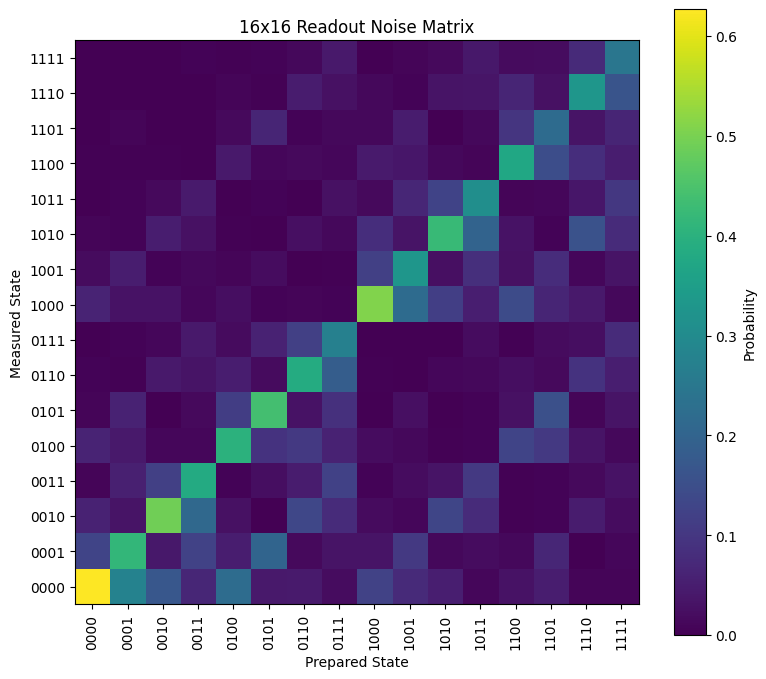


RESULTS

Average assignment fidelity = 0.384563

Saved files:
./noise_matrix_results


In [73]:
# ============================================================
# RUN
# ============================================================
if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved matrix
noise_matrix = np.load("noise_matrix_results/noise_matrix_16x16.npy")

# Plot
plt.figure(figsize=(5,4))

plt.imshow(noise_matrix, origin="lower")

plt.colorbar(label="Probability")

tick_labels = [format(i, "04b") for i in range(16)]

plt.xticks(range(16), tick_labels, rotation=90)
plt.yticks(range(16), tick_labels)

plt.xlabel("Prepared State")
plt.ylabel("Measured State")

plt.title("16x16 Readout Noise Matrix")

plt.tight_layout()

plt.show()

In [ ]:
    # Fidelity
    # --------------------------------------------------------
fidelity = np.mean(np.diag(noise_matrix))
print("\n================================================")
print("RESULTS")
print("================================================")
print(f"\nAverage assignment fidelity = {fidelity:.6f}")
print("\nSaved files:")
print(SAVE_DIR)

In [ ]:
print(noise_matrix.sum(axis=0))
diag = np.diag(noise_matrix)
print(diag)

# روش دوم

In [79]:
# ============================================================
# BUILD 16x16 READOUT NOISE MATRIX FROM REAL IQ DATA
# ===========================================================
# Input:
#   16 files:
#       0000.txt ... 1111.txt
# File structure:
#   - 4 lines per file
#   - each line = one qubit
#   - each line = 1000 complex IQ samples
# Output
#   1) Single-qubit assignment matrices
#   2) Full 16x16 readout noise matrix
#   3) Heatmap visualization
#   4) Saved numpy files
# ============================================================
# ============================================================
# REAL READOUT NOISE MATRIX EXTRACTION
# WITH TRAIN / TEST SEPARATION
# ============================================================
import os
import glob
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score
# ============================================================
# CONFIG
DATA_DIR = "./quadrature_data_4qubits"
NUM_QUBITS = 4
NUM_STATES = 16
SHOTS_PER_FILE = 1000
RANDOM_SEED = 42
SAVE_DIR = "./noise_matrix_results"
os.makedirs(SAVE_DIR, exist_ok=True)
# ============================================================
# PARSE COMPLEX
def parse_complex_string(s):
    s = s.strip()
    if s.startswith("(") and s.endswith(")"):
        s = s[1:-1]
    return complex(s)
# ============================================================
# LOAD SINGLE FILE
def load_single_file(file_path):
    with open(file_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]
    if len(lines) != 4:
        raise ValueError(f"{file_path}: expected 4 lines")
    qubit_arrays = []
    for line in lines:
        tokens = line.split()
        vals = [parse_complex_string(tok) for tok in tokens]
        arr = np.array(vals, dtype=np.complex128)
        if arr.size != SHOTS_PER_FILE:
            raise ValueError(
                f"{file_path}: expected {SHOTS_PER_FILE} samples"
            )
        qubit_arrays.append(arr)
    return np.stack(qubit_arrays, axis=0)
# ============================================================
# FILE NAME -> LABEL
def bits_from_filename(filename):
    base = os.path.splitext(
        os.path.basename(filename)
    )[0]
    bits = [int(b) for b in base[::-1]]
    return np.array(bits, dtype=int)
# ============================================================
# BITS <-> INTEGER
def bits_to_int(bits):
    q1, q2, q3, q4 = bits
    return (
        q1
        + 2*q2
        + 4*q3
        + 8*q4
    )
def int_to_bits(x):
    return np.array([
        (x >> 0) & 1,
        (x >> 1) & 1,
        (x >> 2) & 1,
        (x >> 3) & 1,
    ])
# ============================================================
# LOAD COMPLETE DATASET
# ============================================================
def load_all_data():
    pattern = os.path.join(
        DATA_DIR,
        "[01][01][01][01].txt"
    )
    file_paths = glob.glob(pattern)
    file_paths = sorted(
        file_paths,
        key=lambda fp: int(
            os.path.splitext(
                os.path.basename(fp)
            )[0],
            2
        )
    )
    all_X = []
    all_y = []
    for fp in file_paths:
        print(f"Loading {os.path.basename(fp)}")
        data = load_single_file(fp)
        labels = bits_from_filename(fp)
        # (4,1000) -> (1000,4)
        X_block = data.T
        y_block = np.tile(
            labels,
            (SHOTS_PER_FILE,1)
        )
        all_X.append(X_block)
        all_y.append(y_block)
    X = np.vstack(all_X)
    y = np.vstack(all_y)
    print("\nFinal dataset shape:")
    print("X:", X.shape)
    print("y:", y.shape)
    return X, y
# ============================================================
# VISUALIZE IQ CLOUDS
def plot_qubit_iq_clouds(X, y, qubit_index):
    z = X[:, qubit_index]
    mask0 = y[:, qubit_index] == 0
    mask1 = y[:, qubit_index] == 1
    z0 = z[mask0]
    z1 = z[mask1]
    plt.figure(figsize=(5,5))
    plt.scatter(
        z0.real,
        z0.imag,
        s=8,
        alpha=0.4,
        label="State 0"
    )
    plt.scatter(
        z1.real,
        z1.imag,
        s=8,
        alpha=0.4,
        label="State 1"
    )
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.title(f"Qubit {qubit_index+1} IQ Clouds")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
# ============================================================
# TRAIN CLASSIFIER FOR ONE QUBIT
def train_single_qubit_classifier(
    X,
    y,
    qubit_index,
    test_size=0.2
):
    print("\n================================================")
    print(f"QUBIT {qubit_index+1}")
    print("================================================")
    z = X[:, qubit_index]
    features = np.column_stack([
        z.real,
        z.imag
    ])
    labels = y[:, qubit_index]
    # --------------------------------------------------------
    # TRAIN / TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=test_size,
        random_state=RANDOM_SEED,
        stratify=labels
    )
    print("\nTrain size:", X_train.shape[0])
    print("Test size :", X_test.shape[0])
    # --------------------------------------------------------
    # TRAIN
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train, y_train)
    # --------------------------------------------------------
    # TEST PREDICTION
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nTest Accuracy = {acc:.6f}")
    # --------------------------------------------------------
    # ASSIGNMENT MATRIX
    A = confusion_matrix(
        y_test,
        y_pred,
        labels=[0,1],
        normalize="true"
    )
    print("\nSingle-Qubit Assignment Matrix:\n")
    print(A)
    np.save(
            os.path.join(
                SAVE_DIR,
                f"assignment_matrix_q{qubit_index+1}.npy"
            ),
            A
        )
    return clf, A
# ============================================================
# TRAIN ALL CLASSIFIERS
def train_all_classifiers(X, y):
    classifiers = []
    assignment_matrices = []
    for q in range(NUM_QUBITS):
        clf, A = train_single_qubit_classifier(
            X,
            y,
            q
        )
        classifiers.append(clf)
        assignment_matrices.append(A)
    return classifiers, assignment_matrices
# ============================================================
# PREDICT FULL DATASET
def predict_full_dataset(X, classifiers):
    N = X.shape[0]
    y_pred = np.zeros((N, NUM_QUBITS), dtype=int)
    for q in range(NUM_QUBITS):
        z = X[:, q]
        features = np.column_stack([
            z.real,
            z.imag
        ])
        pred = classifiers[q].predict(features)
        y_pred[:, q] = pred
    return y_pred
# ============================================================
# BUILD 16x16 NOISE MATRIX
def build_noise_matrix(y_true, y_pred):
    M = np.zeros((16,16))
    for prep_state in range(16):
        prep_bits = int_to_bits(prep_state)
        mask = np.all(
            y_true == prep_bits,
            axis=1
        )
        subset = y_pred[mask]
        total = subset.shape[0]
        for bits in subset:
            meas_state = bits_to_int(bits)
            M[meas_state, prep_state] += 1
        M[:, prep_state] /= total
    return M
# ============================================================
# CHECK MATRIX VALIDITY
def validate_noise_matrix(M):
    print("\n================================================")
    print("VALIDATION")
    print("================================================")
    col_sums = M.sum(axis=0)
    print("\nColumn sums:\n")
    print(col_sums)

    diag = np.diag(M)
    print("\nDiagonal elements:\n")
    print(diag)
    print("\nAverage diagonal fidelity:")
    print(np.mean(diag))
# ============================================================
# PLOT HEATMAP
def plot_noise_matrix(M):
    plt.figure(figsize=(5,4))
    plt.imshow(M, origin="lower")
    plt.colorbar(label="Probability")
    labels = [
        format(i, "04b")
        for i in range(16)
    ]
    plt.xticks(range(16), labels, rotation=90)
    plt.yticks(range(16), labels)
    plt.xlabel("Prepared State")
    plt.ylabel("Measured State")
    plt.title("16x16 Readout Noise Matrix")
    plt.tight_layout()
    out_path = os.path.join(
    SAVE_DIR,
    "noise_matrix_heatmap.png"
    )
    plt.savefig(out_path, dpi=300)
    plt.show()
# SAVE MATRIX
# ============================================================
def save_noise_matrix(M):

    np.save(
        os.path.join(
            SAVE_DIR,
            "noise_matrix_16x16.npy"
        ),
        M
    )
    np.savetxt(
        os.path.join(
            SAVE_DIR,
            "noise_matrix_16x16.txt"
        ),
        M,
        fmt="%.8f"
    )

 ============================================================

## WORKFLOW

 ============================================================

In [80]:
# ------------------------------------------------------------
# STEP 1
# Load data
# ------------------------------------------------------------

X, y = load_all_data()

Loading 0000.txt
Loading 0001.txt
Loading 0010.txt
Loading 0011.txt
Loading 0100.txt
Loading 0101.txt
Loading 0110.txt
Loading 0111.txt
Loading 1000.txt
Loading 1001.txt
Loading 1010.txt
Loading 1011.txt
Loading 1100.txt
Loading 1101.txt
Loading 1110.txt
Loading 1111.txt

Final dataset shape:
X: (16000, 4)
y: (16000, 4)


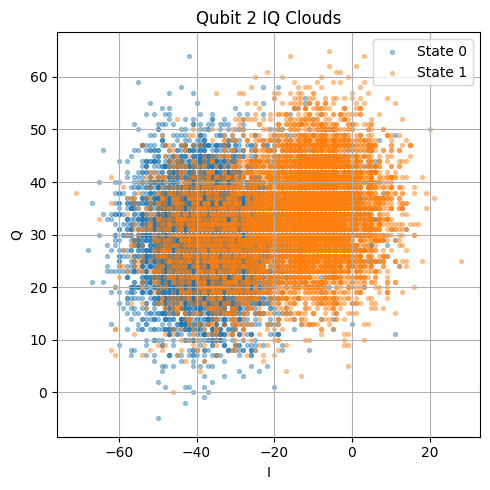

In [81]:
# ------------------------------------------------------------
# STEP 2
# Visualize IQ clouds
# ------------------------------------------------------------

# Example:
plot_qubit_iq_clouds(X, y, qubit_index=1)

In [82]:
# ------------------------------------------------------------
# STEP 3
# Train classifiers
# ------------------------------------------------------------

classifiers, assignment_matrices = train_all_classifiers(X, y)


QUBIT 1

Train size: 12800
Test size : 3200

Test Accuracy = 0.712812

Single-Qubit Assignment Matrix:

[[0.7944 0.2056]
 [0.3688 0.6312]]

QUBIT 2

Train size: 12800
Test size : 3200

Test Accuracy = 0.819375

Single-Qubit Assignment Matrix:

[[0.8744 0.1256]
 [0.2356 0.7644]]

QUBIT 3

Train size: 12800
Test size : 3200

Test Accuracy = 0.804375

Single-Qubit Assignment Matrix:

[[0.885  0.115 ]
 [0.2762 0.7238]]

QUBIT 4

Train size: 12800
Test size : 3200

Test Accuracy = 0.820312

Single-Qubit Assignment Matrix:

[[0.8919 0.1081]
 [0.2512 0.7488]]


In [83]:
# ------------------------------------------------------------
# STEP 4
# Predict all shots
# ------------------------------------------------------------

y_pred = predict_full_dataset(X, classifiers)

In [84]:
# ------------------------------------------------------------
# STEP 5
# Build full noise matrix
# ------------------------------------------------------------

noise_matrix = build_noise_matrix(y, y_pred)
fidelity = np.mean(np.diag(noise_matrix))
print(f"\nAverage assignment fidelity = {fidelity:.6f}")


Average assignment fidelity = 0.384875


In [85]:
# ------------------------------------------------------------
# STEP 6
# Validate
# ------------------------------------------------------------

validate_noise_matrix(noise_matrix)


VALIDATION

Column sums:

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Diagonal elements:

[0.626 0.414 0.489 0.379 0.411 0.439 0.387 0.275 0.508 0.328 0.42  0.305
 0.377 0.218 0.334 0.248]

Average diagonal fidelity:
0.38487499999999997


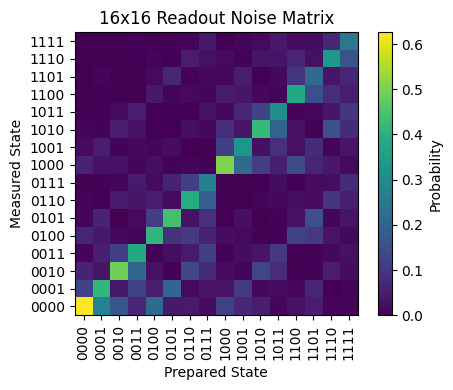

In [86]:
# ------------------------------------------------------------
# STEP 7
# Plot
# ------------------------------------------------------------

plot_noise_matrix(noise_matrix)

In [87]:
# ------------------------------------------------------------
# STEP 8
# Save
# ------------------------------------------------------------

save_noise_matrix(noise_matrix)